In [1]:
# --- 1. Setup and Configuration ---
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import pandas as pd
import numpy as np
import urllib.request
from PIL import Image
from tqdm.auto import tqdm
import joblib

# PyTorch and Deep Learning Libraries
import torch
import torch.nn as nn
from transformers import CLIPProcessor, CLIPModel, AutoModel, AutoTokenizer
from efficientnet_pytorch import EfficientNet
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

# --- ENVIRONMENT SETUP ---
DATA_DIR = "../data"
IMAGES_DIR = os.path.join(DATA_DIR, "images")
MODELS_DIR = "../results/models"

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(IMAGES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# --- CONFIGURATION: DATASET SAMPLING RATIOS ---
# Adjust these ratios based on your machine's capabilities and training time
TRAIN_RATIO = 0.05  # Use 5% of the original training data (~27,000 samples)
VAL_RATIO = 0.5     # Use 50% of the original validation set
TEST_RATIO = 0.5    # Use 50% of the original test set

# Define file paths (Assume TSV files are in the current working directory or /data)
TRAIN_FILE = os.path.join(DATA_DIR, "multimodal_train.tsv") 
VAL_FILE = os.path.join(DATA_DIR, "multimodal_validate.tsv") 
TEST_FILE = os.path.join(DATA_DIR, "multimodal_test_public.tsv")

tqdm.pandas()

Using device: cpu


In [2]:
# --- Data Loading Functions ---
def load_split(path, split_name):
    """Loads a single TSV file split."""
    if not os.path.exists(path):
        print(f"Error: {path} not found. Ensure TSV files are in the {DATA_DIR} directory.")
        return pd.DataFrame()
    try:
        df = pd.read_csv(path, sep="\t", on_bad_lines='skip')
        df['split'] = split_name
        df['clean_title'] = df['clean_title'].fillna("")
        df['2_way_label'] = df['2_way_label'].astype(int)
        return df
    except Exception as e:
        print(f"Error loading {path}: {e}")
        return pd.DataFrame()

def stratified_sample_df(df, sample_ratio, label_col='2_way_label'):
    """Performs stratified sampling on the DataFrame."""
    if len(df) == 0 or sample_ratio >= 1.0:
        return df
    
    sample_size = int(len(df) * sample_ratio)
    if sample_size == 0 and len(df) > 0:
        return df.sample(min(1, len(df)), random_state=42)
        
    df_sampled = df.groupby(label_col, group_keys=False).apply(
        lambda x: x.sample(n=int(sample_size * len(x) / len(df)), random_state=42)
    ).reset_index(drop=True)
    return df_sampled

def download_image(row, img_dir):
    """Downloads image if not present and returns success status."""
    if row.get('hasImage') != True:
        return False
        
    img_url = row.get('image_url')
    img_id = row['id']
    img_path = os.path.join(img_dir, f"{img_id}.jpg")
    
    if os.path.exists(img_path):
        return True # Already downloaded

    if pd.isna(img_url) or not img_url:
        return False
        
    try:
        req = urllib.request.Request(img_url, data=None, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=5) as url:
            with open(img_path, 'wb') as f:
                f.write(url.read())
        return True
    except Exception:
        return False

# --- Model Evaluation Function ---
def evaluate_model(model, X, y, name):
    """Trains a classifier and prints macro F1-score."""
    if hasattr(model, 'fit'):
        print(f"\n--- Training {name} Classifier ---")
        model.fit(X['train'], y['train'])
    
    X_test = X['test']
    y_test = y['test']
    
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    
    print(f"\n--- {name} Test Results ---")
    print(f"Macro F1-Score: {report['macro avg']['f1-score']:.4f}")
    print(f"Accuracy: {report['accuracy']:.4f}")
    print("-" * 40)
    
    return report

In [3]:
# 3.1 Load and Sample Data
df_train = load_split(TRAIN_FILE, "train")
df_val = load_split(VAL_FILE, "val")
df_test = load_split(TEST_FILE, "test")

print(f"Original Train size: {len(df_train)}")

df_train_sampled = stratified_sample_df(df_train, TRAIN_RATIO)
df_val_sampled = stratified_sample_df(df_val, VAL_RATIO)
df_test_sampled = stratified_sample_df(df_test, TEST_RATIO)

print(f"Sampled Train size for training: {len(df_train_sampled)}")

# 3.2 Prepare Multimodal Subset and Download Images
df_multimodal = {
    'train': df_train_sampled[df_train_sampled['hasImage'] == True].copy(),
    'val': df_val_sampled[df_val_sampled['hasImage'] == True].copy(),
    'test': df_test_sampled[df_test_sampled['hasImage'] == True].copy()
}

# Download and filter for all multimodal splits
for name, df in df_multimodal.items():
    print(f"Starting download for {name} ({len(df)} samples)...")
    initial_count = len(df)
    df['image_downloaded'] = df.progress_apply(
        lambda row: download_image(row, IMAGES_DIR), axis=1
    )
    df.drop(df[df['image_downloaded'] == False].index, inplace=True)
    print(f"{name} filtered: {len(df)} remaining / {initial_count} initial.")

# Store final filtered dataframes
df_train_final = df_train_sampled.copy() # Use all sampled data for Text-Only
df_val_final = df_val_sampled.copy()
df_test_final = df_test_sampled.copy()

Original Train size: 564000
Sampled Train size for training: 28199
Starting download for train (28199 samples)...


100%|███████████████████████████████████████████████████████████████████████████| 28199/28199 [02:49<00:00, 166.07it/s]


train filtered: 27024 remaining / 28199 initial.
Starting download for val (29671 samples)...


100%|███████████████████████████████████████████████████████████████████████████| 29671/29671 [03:29<00:00, 141.85it/s]


val filtered: 28374 remaining / 29671 initial.
Starting download for test (29658 samples)...


100%|████████████████████████████████████████████████████████████████████████████| 29658/29658 [05:07<00:00, 96.54it/s]


test filtered: 28340 remaining / 29658 initial.


In [4]:
# --- Feature Extraction Function ---
text_model = AutoModel.from_pretrained("distilbert-base-uncased").to(DEVICE)
text_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
text_model.eval()

def extract_text_features(df, split_name):
    print(f"Extracting Text features for {split_name}...")
    features = []
    
    # Use all sampled data for the text baseline
    texts = df['clean_title'].tolist()
    
    for text in tqdm(texts, desc=f"Text Features {split_name}"):
        inputs = text_tokenizer(text, return_tensors="pt", truncation=True, padding='max_length', max_length=50).to(DEVICE)
        with torch.no_grad():
            outputs = text_model(**inputs)
            # Use the [CLS] token output
            features.append(outputs.last_hidden_state[:, 0, :].cpu().numpy().flatten())
            
    return np.array(features)

# --- Execution ---
X_text = {}
y_text = {}

X_text['train'] = extract_text_features(df_train_final, 'Train')
y_text['train'] = df_train_final['2_way_label'].values
X_text['test'] = extract_text_features(df_test_final, 'Test')
y_text['test'] = df_test_final['2_way_label'].values

Extracting Text features for Train...


Text Features Train: 100%|███████████████████████████████████████████████████████| 28199/28199 [27:37<00:00, 17.01it/s]


Extracting Text features for Test...


Text Features Test: 100%|████████████████████████████████████████████████████████| 29658/29658 [28:18<00:00, 17.47it/s]


In [5]:
# Initialize and Evaluate Text Classifier
text_lr_model = LogisticRegression(random_state=42, solver='saga', max_iter=500)

In [6]:
text_report = evaluate_model(text_lr_model, X_text, y_text, "Text-Only (DistilBERT + LR)")


--- Training Text-Only (DistilBERT + LR) Classifier ---

--- Text-Only (DistilBERT + LR) Test Results ---
Macro F1-Score: 0.8152
Accuracy: 0.8243
----------------------------------------


In [7]:
# Save the trained model
joblib.dump(text_lr_model, os.path.join(MODELS_DIR, "text_only_classifier.pkl"))
print(f"Saved Text-Only model to {os.path.join(MODELS_DIR, 'text_only_classifier.pkl')}")

Saved Text-Only model to ../results/models\text_only_classifier.pkl


In [8]:
# --- Feature Extraction Function ---
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()

def calculate_clip_similarity(df, img_dir, split_name):
    print(f"Calculating CLIP Similarity for {split_name}...")
    similarities = []
    
    # Only use filtered multimodal data
    for row in tqdm(df.itertuples(), total=len(df), desc=f"CLIP Scores {split_name}"):
        try:
            img_path = os.path.join(img_dir, f"{row.id}.jpg")
            img = Image.open(img_path).convert("RGB")
            
            inputs = clip_processor(text=[row.clean_title], images=img, return_tensors="pt", padding=True).to(DEVICE)
            
            with torch.no_grad():
                out = clip_model(**inputs)
                img_emb = out.image_embeds.squeeze(0)
                txt_emb = out.text_embeds.squeeze(0)
                
                # Normalize and calculate dot product (cosine similarity)
                img_emb = img_emb / img_emb.norm(dim=-1, keepdim=True)
                txt_emb = txt_emb / txt_emb.norm(dim=-1, keepdim=True)
                similarity = (img_emb * txt_emb).sum().cpu().item()
                similarities.append(similarity)
        except Exception:
            similarities.append(0.0) # Neutral score on error
            
    return np.array(similarities).reshape(-1, 1)

# --- Execution ---
X_clip = {}
y_clip = {}

X_clip['train'] = calculate_clip_similarity(df_multimodal['train'], IMAGES_DIR, 'Train')
y_clip['train'] = df_multimodal['train']['2_way_label'].values
X_clip['test'] = calculate_clip_similarity(df_multimodal['test'], IMAGES_DIR, 'Test')
y_clip['test'] = df_multimodal['test']['2_way_label'].values

# Initialize and Evaluate CLIP Classifier
clip_lr_model = LogisticRegression(random_state=42, solver='liblinear')
clip_report = evaluate_model(clip_lr_model, X_clip, y_clip, "CLIP Similarity (Score + LR)")

# Save the trained model
joblib.dump(clip_lr_model, os.path.join(MODELS_DIR, "clip_lr_model.pkl"))
print(f"Saved CLIP Similarity model to {os.path.join(MODELS_DIR, 'clip_lr_model.pkl')}")

Calculating CLIP Similarity for Train...


CLIP Scores Train: 100%|███████████████████████████████████████████████████████| 27024/27024 [1:15:57<00:00,  5.93it/s]


Calculating CLIP Similarity for Test...


CLIP Scores Test: 100%|████████████████████████████████████████████████████████| 28340/28340 [1:19:07<00:00,  5.97it/s]



--- Training CLIP Similarity (Score + LR) Classifier ---

--- CLIP Similarity (Score + LR) Test Results ---
Macro F1-Score: 0.6809
Accuracy: 0.7090
----------------------------------------
Saved CLIP Similarity model to ../results/models\clip_lr_model.pkl


In [9]:
# --- Feature Extraction Function ---
image_model = EfficientNet.from_pretrained('efficientnet-b0').to(DEVICE)
image_model._fc = nn.Identity() # Remove final layer
image_model.eval()

def extract_image_features_and_ids(df, img_dir, split_name):
    """Extracts features and returns both the features array and successful row IDs."""
    print(f"Extracting Image features for {split_name}...")
    features = []
    successful_ids = []
    
    # Only use filtered multimodal data
    for row in tqdm(df.itertuples(), total=len(df), desc=f"Image Features {split_name}"):
        try:
            img_path = os.path.join(img_dir, f"{row.id}.jpg")
            img = Image.open(img_path).convert("RGB").resize((224, 224))
            
            # Simple preprocessing
            img_tensor = torch.tensor(np.array(img)).permute(2, 0, 1).float() / 255.0
            img_tensor = (img_tensor - 0.5) / 0.5 
            img_tensor = img_tensor.unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                features.append(image_model(img_tensor).cpu().numpy().flatten())
                successful_ids.append(row.id) # <-- TRACK THE SUCCESSFUL ID
        except Exception as e:
            # The feature extraction failed for this row, skip it.
            pass
            
    return np.array(features), successful_ids # RETURN FEATURES AND IDs

# --- CORRECTED EXECUTION ---
X_image = {}
y_image = {}

# Train Split
X_train_img, successful_train_ids = extract_image_features_and_ids(df_multimodal['train'], IMAGES_DIR, 'Train')
# Filter the labels DataFrame to match only the successful IDs
y_train_img_df = df_multimodal['train'][df_multimodal['train']['id'].isin(successful_train_ids)] 
X_image['train'] = X_train_img
y_image['train'] = y_train_img_df['2_way_label'].values # Labels are now aligned

# Test Split
X_test_img, successful_test_ids = extract_image_features_and_ids(df_multimodal['test'], IMAGES_DIR, 'Test')
y_test_img_df = df_multimodal['test'][df_multimodal['test']['id'].isin(successful_test_ids)]
X_image['test'] = X_test_img
y_image['test'] = y_test_img_df['2_way_label'].values

# Initialize and Evaluate Image Classifier (This step will now succeed)
image_lr_model = LogisticRegression(random_state=42, solver='saga', max_iter=500)
image_report = evaluate_model(image_lr_model, X_image, y_image, "Image-Only (EfficientNet + LR)")

# Save the trained model
joblib.dump(image_lr_model, os.path.join(MODELS_DIR, "image_only_classifier.pkl"))
print(f"Saved Image-Only model to {os.path.join(MODELS_DIR, 'image_only_classifier.pkl')}")

Loaded pretrained weights for efficientnet-b0
Extracting Image features for Train...


Image Features Train: 100%|██████████████████████████████████████████████████████| 27024/27024 [34:39<00:00, 13.00it/s]


Extracting Image features for Test...


Image Features Test: 100%|███████████████████████████████████████████████████████| 28340/28340 [36:10<00:00, 13.06it/s]



--- Training Image-Only (EfficientNet + LR) Classifier ---

--- Image-Only (EfficientNet + LR) Test Results ---
Macro F1-Score: 0.6921
Accuracy: 0.7141
----------------------------------------
Saved Image-Only model to ../results/models\image_only_classifier.pkl


In [10]:
# --- Feature Extraction Function ---
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()

def calculate_clip_similarity_and_ids(df, img_dir, split_name):
    """Calculates CLIP Similarity and returns both the features array and successful row IDs."""
    print(f"Calculating CLIP Similarity for {split_name}...")
    similarities = []
    successful_ids = []
    
    for row in tqdm(df.itertuples(), total=len(df), desc=f"CLIP Scores {split_name}"):
        try:
            img_path = os.path.join(img_dir, f"{row.id}.jpg")
            img = Image.open(img_path).convert("RGB")
            
            inputs = clip_processor(text=[row.clean_title], images=img, return_tensors="pt", padding=True).to(DEVICE)
            
            with torch.no_grad():
                out = clip_model(**inputs)
                img_emb = out.image_embeds.squeeze(0)
                txt_emb = out.text_embeds.squeeze(0)
                
                img_emb = img_emb / img_emb.norm(dim=-1, keepdim=True)
                txt_emb = txt_emb / txt_emb.norm(dim=-1, keepdim=True)
                similarity = (img_emb * txt_emb).sum().cpu().item()
                
                similarities.append(similarity)
                successful_ids.append(row.id) # <-- TRACK THE SUCCESSFUL ID
        except Exception:
            pass
            
    return np.array(similarities).reshape(-1, 1), successful_ids

# --- CORRECTED EXECUTION ---
X_clip = {}
y_clip = {}

# Train Split
X_train_clip, successful_train_ids = calculate_clip_similarity_and_ids(df_multimodal['train'], IMAGES_DIR, 'Train')
# Filter the labels DataFrame to match only the successful IDs
y_train_clip_df = df_multimodal['train'][df_multimodal['train']['id'].isin(successful_train_ids)] 
X_clip['train'] = X_train_clip
y_clip['train'] = y_train_clip_df['2_way_label'].values

# Test Split
X_test_clip, successful_test_ids = calculate_clip_similarity_and_ids(df_multimodal['test'], IMAGES_DIR, 'Test')
y_test_clip_df = df_multimodal['test'][df_multimodal['test']['id'].isin(successful_test_ids)]
X_clip['test'] = X_test_clip
y_clip['test'] = y_test_clip_df['2_way_label'].values

# Initialize and Evaluate CLIP Classifier (This step will now succeed)
clip_lr_model = LogisticRegression(random_state=42, solver='liblinear')
clip_report = evaluate_model(clip_lr_model, X_clip, y_clip, "CLIP Similarity (Score + LR)")

# Save the trained model
joblib.dump(clip_lr_model, os.path.join(MODELS_DIR, "clip_lr_model.pkl"))
print(f"Saved CLIP Similarity model to {os.path.join(MODELS_DIR, 'clip_lr_model.pkl')}")

Calculating CLIP Similarity for Train...


CLIP Scores Train: 100%|███████████████████████████████████████████████████████| 27024/27024 [1:14:44<00:00,  6.03it/s]


Calculating CLIP Similarity for Test...


CLIP Scores Test: 100%|████████████████████████████████████████████████████████| 28340/28340 [1:21:26<00:00,  5.80it/s]



--- Training CLIP Similarity (Score + LR) Classifier ---

--- CLIP Similarity (Score + LR) Test Results ---
Macro F1-Score: 0.6808
Accuracy: 0.7088
----------------------------------------
Saved CLIP Similarity model to ../results/models\clip_lr_model.pkl


=== DELIVERABLE 2: BASELINE MODEL SUMMARY ===
                              Accuracy  Macro F1-Score  F1 (FAKE Class)  \
Model                                                                     
Text-Only (DistilBERT+LR)       0.8243          0.8152           0.8562   
Image-Only (EfficientNet+LR)    0.7141          0.6921           0.7744   
CLIP Similarity (Score+LR)      0.7088          0.6808           0.7753   

                              F1 (REAL Class)  
Model                                          
Text-Only (DistilBERT+LR)              0.7742  
Image-Only (EfficientNet+LR)           0.6099  
CLIP Similarity (Score+LR)             0.5863  




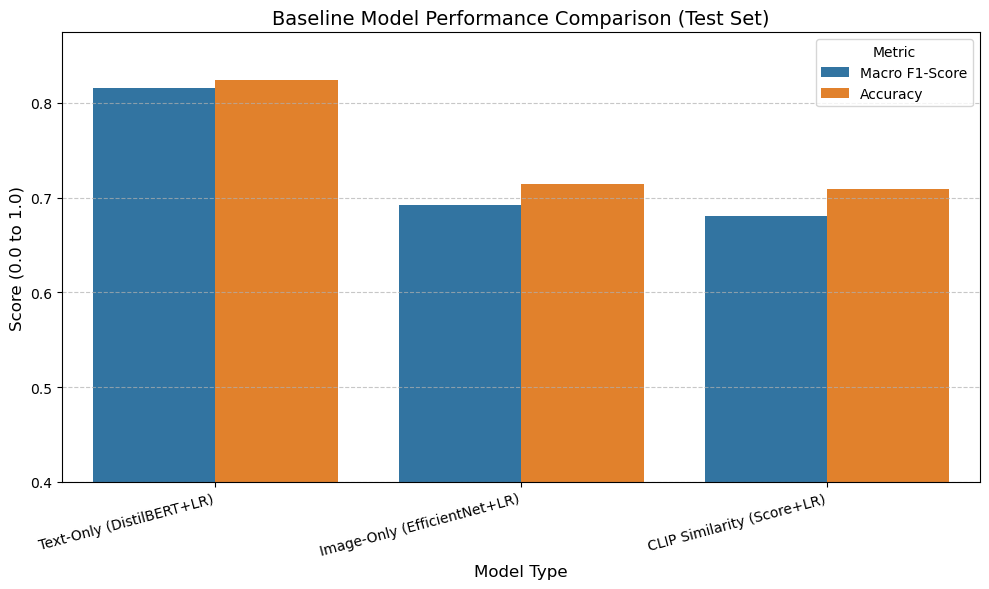


=== SAMPLE PREDICTIONS (CLIP Similarity) ===

--- Result: CORRECT ---
ID: cev2w0a
Title: other discussions...
True Label: FAKE (Prob REAL: 0.113)
Predicted: FAKE (CLIP Sim: 0.182)


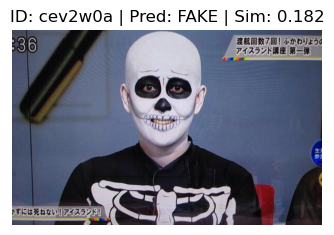


--- Result: CORRECT ---
ID: d1ujwlb
Title: keanu love...
True Label: FAKE (Prob REAL: 0.274)
Predicted: FAKE (CLIP Sim: 0.240)


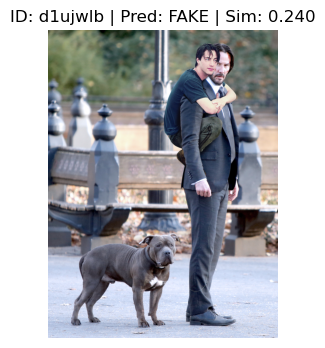


--- Result: CORRECT ---
ID: 2c53hl
Title: tiger swimming x...
True Label: REAL (Prob REAL: 0.567)
Predicted: REAL (CLIP Sim: 0.307)


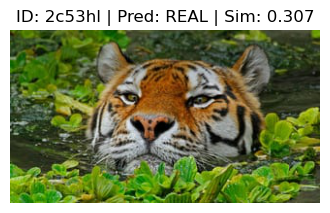


--- Result: INCORRECT ---
ID: we69u
Title: calls to destroy egypts great pyramids begin...
True Label: REAL (Prob REAL: 0.068)
Predicted: FAKE (CLIP Sim: 0.153)


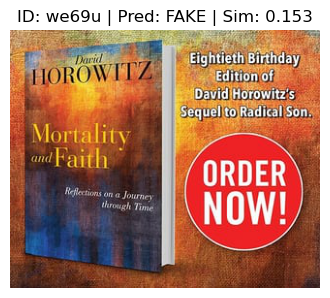


--- Result: INCORRECT ---
ID: 8tqjqq
Title: syrian refugee in iraq sets up vet to rescue help injured animals...
True Label: REAL (Prob REAL: 0.421)
Predicted: FAKE (CLIP Sim: 0.275)


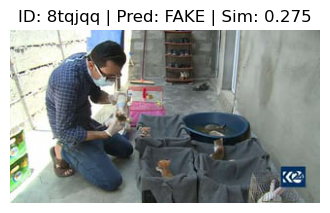

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Ensure the results from sections 4, 5, and 6 are available:
# text_report, image_report, clip_report
# X_text['test'], y_text['test'], text_lr_model
# X_image['test'], y_image['test'], image_lr_model
# X_clip['test'], y_clip['test'], clip_lr_model

# --- 7.1 Aggregate Results Table ---

# List of reports generated in previous steps
reports = {
    "Text-Only (DistilBERT+LR)": text_report,
    "Image-Only (EfficientNet+LR)": image_report,
    "CLIP Similarity (Score+LR)": clip_report
}

summary_data = []

for name, report in reports.items():
    # Extract overall metrics
    macro_f1 = report['macro avg']['f1-score']
    accuracy = report['accuracy']
    
    # Extract class-specific F1-scores
    f1_fake = report.get('0', {}).get('f1-score', 0.0) # Class 0 = FAKE
    f1_real = report.get('1', {}).get('f1-score', 0.0) # Class 1 = REAL
    
    summary_data.append({
        "Model": name,
        "Accuracy": accuracy,
        "Macro F1-Score": macro_f1,
        "F1 (FAKE Class)": f1_fake,
        "F1 (REAL Class)": f1_real
    })

results_df = pd.DataFrame(summary_data).set_index("Model")

print("==============================================")
print("=== DELIVERABLE 2: BASELINE MODEL SUMMARY ===")
print("==============================================")
print(results_df.round(4))
print("\n")


# --- 7.2 Performance Comparison Plot ---

# Prepare data for plotting (using Macro F1-Score)
plot_df = results_df[['Macro F1-Score', 'Accuracy']].reset_index()
plot_df_melted = plot_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=plot_df_melted)
plt.title('Baseline Model Performance Comparison (Test Set)', fontsize=14)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.xlabel('Model Type', fontsize=12)
plt.ylim(0.4, plot_df_melted['Score'].max() + 0.05)
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

# --- 7.3 Sample Predictions (CLIP Baseline) ---
# Use the CLIP baseline as it utilizes both text and image input

print("\n==============================================")
print("=== SAMPLE PREDICTIONS (CLIP Similarity) ===")
print("==============================================")

# 1. Get predictions for the test set
clip_preds = clip_lr_model.predict(X_clip['test'])
clip_probas = clip_lr_model.predict_proba(X_clip['test'])[:, 1] # Probability of REAL class

# 2. Combine results with the test dataframe (filtered)
# Need the filtered test df from section 6 to access IDs, titles, and image paths
df_test_clip = df_multimodal['test'][df_multimodal['test']['id'].isin(y_test_clip_df['id'])]

df_test_clip['CLIP_Sim'] = X_clip['test']
df_test_clip['Prediction'] = clip_preds
df_test_clip['Probability_REAL'] = clip_probas
df_test_clip['Correct'] = (df_test_clip['Prediction'] == df_test_clip['2_way_label']).astype(int)

# 3. Sample 3 Correct and 2 Incorrect predictions for demonstration
sample_correct = df_test_clip[df_test_clip['Correct'] == 1].sample(n=min(3, len(df_test_clip)), random_state=42)
sample_incorrect = df_test_clip[df_test_clip['Correct'] == 0].sample(n=min(2, len(df_test_clip)), random_state=42)

sample_pairs = pd.concat([sample_correct, sample_incorrect]).sort_values(by='Correct', ascending=False)
sample_pairs['Label'] = sample_pairs['2_way_label'].apply(lambda x: 'REAL' if x == 1 else 'FAKE')
sample_pairs['Predicted'] = sample_pairs['Prediction'].apply(lambda x: 'REAL' if x == 1 else 'FAKE')

IMAGES_DIR = "../data/images" # Ensure this path is correct

# Display samples with Image visualization (assuming PIL and Matplotlib are available)
for s in sample_pairs.itertuples():
    result_status = "CORRECT" if s.Correct == 1 else "INCORRECT"
    
    print(f"\n--- Result: {result_status} ---")
    print(f"ID: {s.id}")
    print(f"Title: {s.clean_title[:100]}...")
    print(f"True Label: {s.Label} (Prob REAL: {s.Probability_REAL:.3f})")
    print(f"Predicted: {s.Predicted} (CLIP Sim: {s.CLIP_Sim:.3f})")
    
    try:
        img_path = os.path.join(IMAGES_DIR, f"{s.id}.jpg")
        img = Image.open(img_path).convert("RGB")
        
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.title(f"ID: {s.id} | Pred: {s.Predicted} | Sim: {s.CLIP_Sim:.3f}")
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"Could not load image {s.id}: {e}")